# Importando as principais bibliotecas que serão utilizadas no projeto.


In [90]:
import numpy as np
import matplotlib.pyplot as plt

In [91]:
# Definindo o estilo
plt.style.use("dark_background")
plt.rcParams['figure.figsize'] = [10,8]

# Criando dataset

In [92]:
# x = temperatura em graus Celsius
# w = Curva da reta
# b = bias

# Equação da reta
def get_linear_curve(x, w, b = 0, noise_scale = 0):
  return w * x + b + noise_scale * np.random.randn(x.shape[0])

# np.random.randn(x.shape[0]) = Ruído

In [93]:
x = np.arange(-10,31,1)
Y = get_linear_curve(x,1.8,32, noise_scale=5)

In [94]:
x.shape, Y.shape

((41,), (41,))

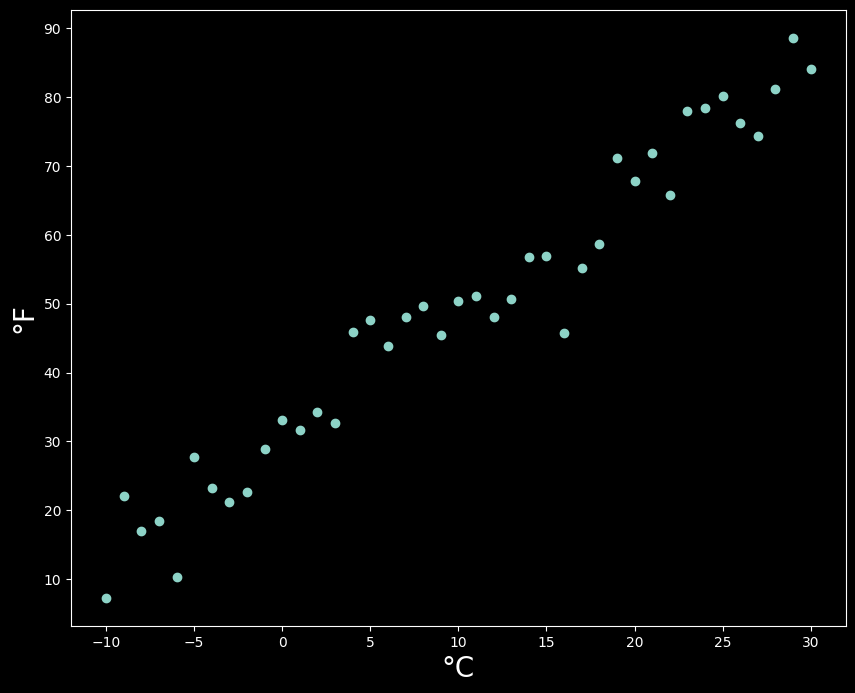

In [95]:
plt.scatter(x,Y)
plt.xlabel("°C", fontsize=20);
plt.ylabel("°F", fontsize=20);

# Modelo



- Inicializar os pesos e bias
- Feedforward
- Calcular Perda
- Backprogation

In [96]:
# Inicializar

w = np.random.randn(1)
b = 0

In [97]:
# Geralmente entrada é encontrada como "Input" utilizei entrada para nível de aprendizagem

def forward(entrada, w, b):
  return w * entrada + b

In [98]:
# Função de perda ou erro
def mse(Y,y):
  return (Y-y) ** 2

In [99]:
# Exemplo de uso

v = np.array([1, 2, 3, 4, 5])
u = np.array([1.1, 2.2, 3.4, 4.8, 6])
mse(v,u)

array([0.01, 0.04, 0.16, 0.64, 1.  ])

In [100]:
# target = valor real = valor quero chegar
#lr = learning rating = taxa de aprendizado

# backpropagation serve para calcular a derivada do erro em relação ao peso e a derivada do erro com relação ao bias.

def backpropagation(entrada, saida, target, w, b, lr):
  dw = lr * ( -2 * entrada * (target - saida)).mean() #Geralmente não tem o mean mas como são vários valores por ser um vetor está tirando a média
  db = lr * ( -2 * (target - saida)).mean()

  w -= dw
  b -= db

  return w,b

In [111]:
def model_fit(entrada,target, w, b, epochs = 100, lr = 0.01):
  for epoch in range(epochs):

    saida = forward(entrada, w, b)
    perda = np.mean(mse(target,saida))
    w,b = backpropagation(entrada, saida, target, w, b, lr)

    if (epoch+1) % 10 == 0:
      print(f'Epoch: [{epoch+1}] Perda: [{perda:.4f}])')


  return w, b



In [107]:
x = np.arange(-10,31,1)
Y = get_linear_curve(x, w = 1.8, b = 32)

In [108]:
# Inicialização

w = np.random.randn(1)
b = np.zeros(1)


In [112]:
w, b = model_fit(x, Y, w, b, epochs = 501, lr = 0.001)
print('')
print(f'W = {w[0]:.3f} B = {b[0]:.3F} ')

Epoch: [10] Perda: [180.2920])
Epoch: [20] Perda: [176.1387])
Epoch: [30] Perda: [172.0810])
Epoch: [40] Perda: [168.1168])
Epoch: [50] Perda: [164.2439])
Epoch: [60] Perda: [160.4602])
Epoch: [70] Perda: [156.7637])
Epoch: [80] Perda: [153.1524])
Epoch: [90] Perda: [149.6242])
Epoch: [100] Perda: [146.1773])
Epoch: [110] Perda: [142.8099])
Epoch: [120] Perda: [139.5200])
Epoch: [130] Perda: [136.3059])
Epoch: [140] Perda: [133.1658])
Epoch: [150] Perda: [130.0981])
Epoch: [160] Perda: [127.1010])
Epoch: [170] Perda: [124.1730])
Epoch: [180] Perda: [121.3125])
Epoch: [190] Perda: [118.5178])
Epoch: [200] Perda: [115.7875])
Epoch: [210] Perda: [113.1201])
Epoch: [220] Perda: [110.5142])
Epoch: [230] Perda: [107.9683])
Epoch: [240] Perda: [105.4811])
Epoch: [250] Perda: [103.0511])
Epoch: [260] Perda: [100.6771])
Epoch: [270] Perda: [98.3578])
Epoch: [280] Perda: [96.0920])
Epoch: [290] Perda: [93.8783])
Epoch: [300] Perda: [91.7157])
Epoch: [310] Perda: [89.6028])
Epoch: [320] Perda: [8

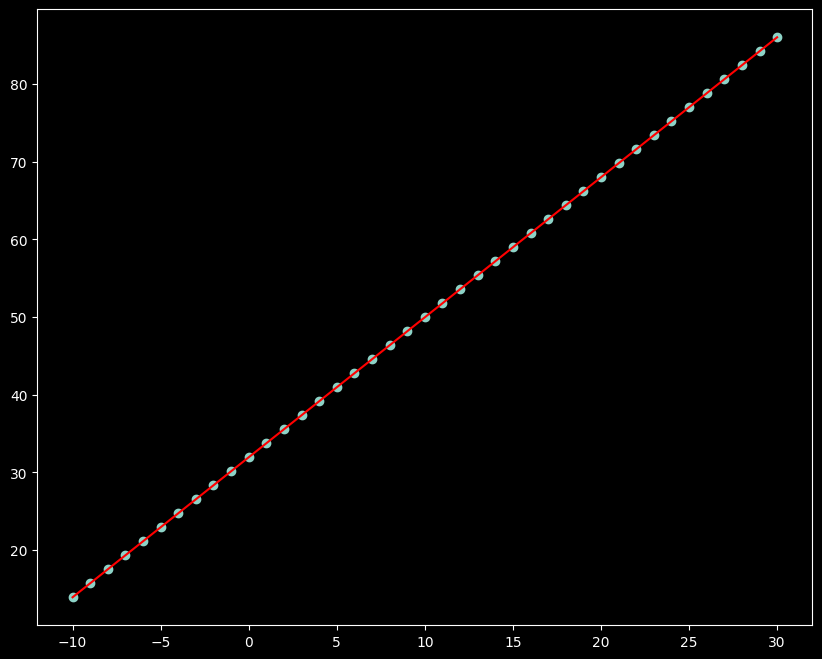

In [89]:
plt.scatter(x,Y)
plt.plot(x, w * x + b, color='red');
